# Sleep Disorder Detection — Kaggle Training

**Dataset:** CAP Sleep Database (pre-processed CSV)  
**Task:** Phân loại 7 sleep disorders từ single-channel EEG (C4-A1, 512 Hz)  
**Model:** XGBoost (GPU) + MLflow tracking  

| File | Label |
|---|---|
| bal_healthy.csv | healthy |
| bal_nfle.csv | nfle |
| bal_ins.csv | insomnia |
| bal_narco.csv | narcolepsy |
| bal_plm.csv | plm |
| bal_rbd.csv | rbd |
| bal_sdb.csv | sdb |

Chạy **Run All** → tải `sleep_model_export.zip` từ tab Output.

In [ ]:
%pip install -q mlflow xgboost lightgbm scikit-learn imbalanced-learn scipy pandas numpy matplotlib seaborn tqdm
print("Libraries installed.")

Note: you may need to restart the kernel to use updated packages.
Libraries installed.


In [ ]:
import os, pickle, json, zipfile, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import entropy as scipy_entropy, skew, kurtosis as scipy_kurtosis
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import lightgbm as lgb
from tqdm import tqdm
import mlflow, mlflow.sklearn

# Detect GPU
import subprocess
try:
    subprocess.check_output(["nvidia-smi"], stderr=subprocess.DEVNULL)
    DEVICE = "cuda"
    LGB_DEVICE = "gpu"
except Exception:
    DEVICE = "cpu"
    LGB_DEVICE = "cpu"

print(f"Device  : {DEVICE}")
print(f"MLflow  : {mlflow.__version__}")
print(f"XGBoost : {__import__('xgboost').__version__}")
print(f"LightGBM: {lgb.__version__}")

Device : cuda
MLflow : 3.11.1


## 1. Config

In [ ]:
DATA_DIR   = Path("/kaggle/input/datasets/shrutimurarka/cap-sleep-unbalanced-dataset/Balanced Data/Balanced Data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data/kaggle")

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_TRACKING_URI = str(OUTPUT_DIR / "mlruns")
EXPERIMENT_NAME     = "sleep-disorder-kaggle"

SFREQ       = 512
WIN_SAMPLES = 1024

# Per-class row limit: cap large classes, load all small classes
# nfle (~240k rows), rbd (~170k rows) → cap to balance training set
# sdb (1,565 rows), healthy (9,305) → load all
MAX_PER_CLASS = {
    "healthy"   : None,    # ~9,305  — load all
    "nfle"      : 20_000,  # cap (file is 1.97 GB)
    "insomnia"  : None,    # ~9,959  — load all
    "narcolepsy": None,    # ~9,557  — load all
    "plm"       : None,    # ~17,933 — load all
    "rbd"       : 20_000,  # cap (file is 1.15 GB)
    "sdb"       : None,    # ~1,565  — load all (minority class)
}

print(f"Data dir : {DATA_DIR}")
print(f"Output   : {OUTPUT_DIR}")
print(f"Per-class limits : { {k: v if v else 'all' for k, v in MAX_PER_CLASS.items()} }")

Data dir      : /kaggle/input/datasets/shrutimurarka/cap-sleep-unbalanced-dataset/Balanced Data/Balanced Data
Output dir    : /kaggle/working
Rows per file : 50,000


## 2. Check Data

In [38]:
DISEASE_FILES = {
    "healthy"   : "bal_healthy.csv",
    "nfle"      : "bal_nfle.csv",
    "insomnia"  : "bal_ins.csv",
    "narcolepsy": "bal_narco.csv",
    "plm"       : "bal_plm.csv",
    "rbd"       : "bal_rbd.csv",
    "sdb"       : "bal_sdb.csv",
}

available = {}
for label, fname in DISEASE_FILES.items():
    fpath = DATA_DIR / fname
    if fpath.exists():
        available[label] = fpath
        print(f"  [OK] {label:<12} {fpath.stat().st_size/1e6:>8.1f} MB")
    else:
        print(f"  [--] {label:<12} NOT FOUND")

print(f"\n{len(available)}/{len(DISEASE_FILES)} files found")

  [OK] healthy         243.3 MB
  [OK] nfle           1975.4 MB
  [OK] insomnia        260.3 MB
  [OK] narcolepsy      249.8 MB
  [OK] plm             468.8 MB
  [OK] rbd            1152.8 MB
  [OK] sdb              40.9 MB

7/7 files found


In [39]:
if available:
    fpath = next(iter(available.values()))
    peek = pd.read_csv(fpath, nrows=2)
    print(f"Shape   : {peek.shape[1]} cols  ({WIN_SAMPLES} signal + 1 label)")
    print(f"Label   : column '{peek.columns[-1]}', values = {sorted(peek.iloc[:, -1].unique())}")
    print(f"Dtype   : {peek.dtypes.iloc[0]}")
    print(peek.iloc[:, [0, 1, -2, -1]])

Shape   : 1025 cols  (1024 signal + 1 label)
Label   : column '0.000000000000000000e+00', values = [np.float64(0.0)]
Dtype   : float64
   -1.723137973137972523e+01  -1.671245421245420815e+01  \
0                   9.020147                   8.470696   
1                  -8.379121                  -8.134921   

   8.165445665445670187e+00  0.000000000000000000e+00  
0                 -8.134921                       0.0  
1                  5.540293                       0.0  


## 3. Feature Extraction (24 features / window)

| Group | Features (count) |
|---|---|
| Band power absolute | delta, theta, alpha, beta, gamma (5) |
| Relative band power | delta_rel … gamma_rel (5) |
| Spectral | spectral_entropy, peak_frequency, mean_frequency (3) |
| Amplitude | amplitude_mean, amplitude_std, rms (3) |
| Ratios | delta_beta_ratio, theta_alpha_ratio (2) |
| Time-domain | skewness, kurtosis, zero_crossing_rate (3) |
| Hjorth | hjorth_activity, hjorth_mobility, hjorth_complexity (3) |

In [ ]:
FREQ_BANDS = {
    "delta": (0.5,  4.0),
    "theta": (4.0,  8.0),
    "alpha": (8.0, 13.0),
    "beta" : (13.0, 30.0),
    "gamma": (30.0, 40.0),
}

def _bandpower(psd, freqs, lo, hi):
    idx = (freqs >= lo) & (freqs <= hi)
    return float(np.trapezoid(psd[idx], freqs[idx])) if idx.any() else 0.0

def extract_features(window: np.ndarray, sfreq: float = 512.0) -> dict:
    w = window.astype(np.float64)
    freqs, psd = scipy_signal.welch(w, fs=sfreq, nperseg=min(256, len(w)))
    total = _bandpower(psd, freqs, 0.5, 40.0) + 1e-12

    f = {}

    # Spectral band features
    for band, (lo, hi) in FREQ_BANDS.items():
        bp = _bandpower(psd, freqs, lo, hi)
        f[f"{band}_power"] = bp
        f[f"{band}_rel"]   = bp / total

    # Spectral descriptors
    psd_n = psd / (psd.sum() + 1e-12)
    f["spectral_entropy"]  = float(scipy_entropy(psd_n + 1e-12))
    f["peak_frequency"]    = float(freqs[np.argmax(psd)])
    f["mean_frequency"]    = float(np.sum(freqs * psd) / (psd.sum() + 1e-12))

    # Amplitude
    f["amplitude_mean"]    = float(np.mean(np.abs(w)))
    f["amplitude_std"]     = float(np.std(w))
    f["rms"]               = float(np.sqrt(np.mean(w ** 2)))

    # Spectral ratios
    f["delta_beta_ratio"]  = f["delta_power"] / (f["beta_power"]  + 1e-12)
    f["theta_alpha_ratio"] = f["theta_power"] / (f["alpha_power"] + 1e-12)

    # Time-domain statistics
    f["skewness"]           = float(skew(w))
    f["kurtosis"]           = float(scipy_kurtosis(w))
    f["zero_crossing_rate"] = float(np.mean(np.diff(np.sign(w)) != 0))

    # Hjorth parameters
    d1   = np.diff(w);  d2 = np.diff(d1)
    var0 = np.var(w)  + 1e-12
    var1 = np.var(d1) + 1e-12
    var2 = np.var(d2) + 1e-12
    f["hjorth_activity"]   = float(var0)
    f["hjorth_mobility"]   = float(np.sqrt(var1 / var0))
    f["hjorth_complexity"] = float(np.sqrt(var2 / var1) / np.sqrt(var1 / var0))

    return f

FEATURE_NAMES = list(extract_features(np.zeros(WIN_SAMPLES)).keys())
print(f"Feature count : {len(FEATURE_NAMES)}")
print(f"Features      : {FEATURE_NAMES}")

Feature count : 18
Feature names : ['delta_power', 'delta_rel', 'theta_power', 'theta_rel', 'alpha_power', 'alpha_rel', 'beta_power', 'beta_rel', 'gamma_power', 'gamma_rel', 'spectral_entropy', 'peak_frequency', 'mean_frequency', 'amplitude_mean', 'amplitude_std', 'rms', 'delta_beta_ratio', 'theta_alpha_ratio']


/tmp/ipykernel_55/2596905279.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0


## 4. Load & Extract

In [ ]:
def load_and_extract(fpath: Path, label: str, nrows: int = None) -> pd.DataFrame:
    df      = pd.read_csv(fpath, nrows=nrows, header=0)
    signals = df.iloc[:, :WIN_SAMPLES].values
    rows    = [extract_features(signals[i]) | {"disease": label}
               for i in tqdm(range(len(signals)), desc=f"{label:<12}", leave=False)]
    return pd.DataFrame(rows)


DISEASE_FILES = {
    "healthy"   : "bal_healthy.csv",
    "nfle"      : "bal_nfle.csv",
    "insomnia"  : "bal_ins.csv",
    "narcolepsy": "bal_narco.csv",
    "plm"       : "bal_plm.csv",
    "rbd"       : "bal_rbd.csv",
    "sdb"       : "bal_sdb.csv",
}

all_dfs = []

if any((DATA_DIR / f).exists() for f in DISEASE_FILES.values()):
    for label, fname in DISEASE_FILES.items():
        fpath = DATA_DIR / fname
        if not fpath.exists():
            print(f"  [--] {label} — file not found, skipping")
            continue
        limit = MAX_PER_CLASS[label]
        df    = load_and_extract(fpath, label, nrows=limit)
        all_dfs.append(df)
        print(f"  {label:<12}  {len(df):>7,} samples  (limit={limit if limit else 'all'})")
else:
    print("No real data — generating synthetic samples")
    np.random.seed(42)
    for label in DISEASE_FILES:
        scale = 1.0 + abs(hash(label)) % 4 * 0.25
        rows  = [extract_features(np.random.randn(WIN_SAMPLES) * scale) | {"disease": label}
                 for _ in range(300)]
        all_dfs.append(pd.DataFrame(rows))
        print(f"  {label:<12}  300 synthetic")

full_df = pd.concat(all_dfs, ignore_index=True)
full_df.to_parquet(OUTPUT_DIR / "features.parquet", index=False)

print(f"\nTotal     : {len(full_df):,} samples | {full_df['disease'].nunique()} classes")
print(full_df["disease"].value_counts().to_string())

healthy     :   0%|          | 0/9305 [00:00<?, ?it/s]/tmp/ipykernel_55/2596905279.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0


  healthy         9,305 samples


nfle        :   0%|          | 0/50000 [00:00<?, ?it/s]/tmp/ipykernel_55/2596905279.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0


  nfle           50,000 samples


insomnia    :   0%|          | 0/9959 [00:00<?, ?it/s]/tmp/ipykernel_55/2596905279.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0


...

  plm            17,933 samples


rbd         :   0%|          | 0/44099 [00:00<?, ?it/s]/tmp/ipykernel_55/2596905279.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0


  rbd            44,099 samples


sdb         :   0%|          | 0/1565 [00:00<?, ?it/s]/tmp/ipykernel_55/2596905279.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0


  sdb             1,565 samples

Total : 142,418 samples | 7 classes
disease
nfle          50000
rbd           44099
plm           17933
insomnia       9959
narcolepsy     9557
healthy        9305
sdb            1565


## 5. EDA

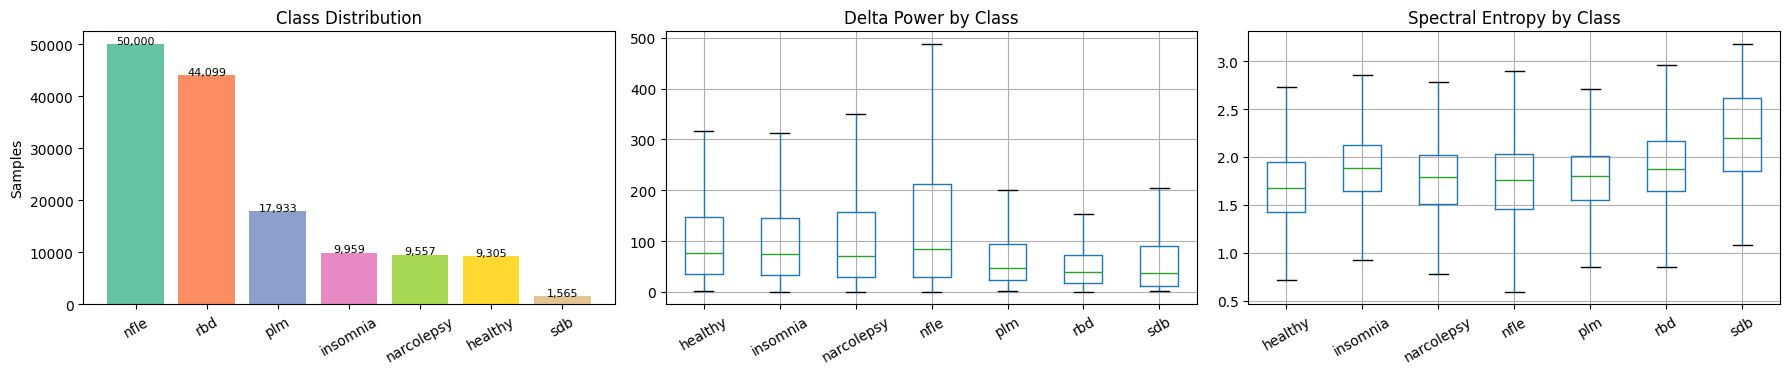

EDA plot saved to eda.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = sns.color_palette("Set2", n_colors=full_df["disease"].nunique())

# --- Class distribution ---
counts = full_df["disease"].value_counts()
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=8)

# --- Delta power by class ---
full_df.boxplot(column="delta_power", by="disease", ax=axes[1], showfliers=False)
axes[1].set_title("Delta Power by Class")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
plt.sca(axes[1]); plt.title("Delta Power by Class")

# --- Spectral entropy by class ---
full_df.boxplot(column="spectral_entropy", by="disease", ax=axes[2], showfliers=False)
axes[2].set_title("Spectral Entropy by Class")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)
plt.sca(axes[2]); plt.title("Spectral Entropy by Class")

plt.suptitle("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda.png", dpi=120, bbox_inches="tight")
plt.show()
print("EDA plot saved to eda.png")

## 6. Prepare & Balance

**Chiến lược cân bằng:**
- Train/val split → giữ val set nguyên (không synthetic)
- Train set: dùng `class_weight="balanced"` cho RF, `sample_weight` cho XGBoost/LightGBM
- `sdb` vẫn ít (1,565) — class weight sẽ bù lại

In [ ]:
le = LabelEncoder()
X  = full_df[FEATURE_NAMES].fillna(0).values.astype(np.float32)
y  = le.fit_transform(full_df["disease"].values)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sample weights for XGBoost / LightGBM
cw             = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
sample_weights = np.array([cw[c] for c in y_train])

print(f"Features : {X.shape[1]}")
print(f"Classes  : {list(le.classes_)}")
print(f"Train    : {len(X_train):,}   Val: {len(X_val):,}")
print()
print(f"{'Class':<12} {'Count (train)':>14} {'Weight':>8}")
print("-" * 36)
for i, cls in enumerate(le.classes_):
    n = int((y_train == i).sum())
    print(f"  {cls:<10} {n:>14,} {cw[i]:>8.3f}")

Features : 18
Classes  : ['healthy', 'insomnia', 'narcolepsy', 'nfle', 'plm', 'rbd', 'sdb']
Train    : 113,934   Val: 28,484
Weights  : {'healthy': np.float64(2.186), 'insomnia': np.float64(2.043), 'narcolepsy': np.float64(2.129), 'nfle': np.float64(0.407), 'plm': np.float64(1.135), 'rbd': np.float64(0.461), 'sdb': np.float64(13.0)}


## 7. Model Comparison

So sánh 3 models: **XGBoost**, **LightGBM**, **Random Forest**  
Mỗi model train trên cùng tập dữ liệu → chọn best F1 (weighted) → lưu vào MLflow.

In [ ]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

# ── Model definitions ────────────────────────────────────────────────────────
MODELS = {
    "XGBoost": XGBClassifier(
        n_estimators     = 500,
        max_depth        = 7,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,
        gamma            = 0.2,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        device           = DEVICE,
        eval_metric      = "mlogloss",
        n_jobs           = -1,
        random_state     = 42,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators     = 500,
        num_leaves       = 63,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 20,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        device_type      = LGB_DEVICE,
        n_jobs           = -1,
        random_state     = 42,
        verbose          = -1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators  = 300,
        max_depth     = None,
        min_samples_split = 10,
        class_weight  = "balanced",
        n_jobs        = -1,
        random_state  = 42,
    ),
}

# ── Training loop ────────────────────────────────────────────────────────────
results = {}

for name, clf in MODELS.items():
    print(f"\n--- {name} ---")
    with mlflow.start_run(run_name=name) as run:
        # Fit
        fit_kwargs = {}
        if name in ("XGBoost", "LightGBM"):
            fit_kwargs["sample_weight"] = sample_weights
        if name == "XGBoost":
            fit_kwargs["eval_set"]  = [(X_val, y_val)]
            fit_kwargs["verbose"]   = 100
        if name == "LightGBM":
            fit_kwargs["eval_set"]  = [(X_val, y_val)]
            callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
            fit_kwargs["callbacks"] = callbacks

        clf.fit(X_train, y_train, **fit_kwargs)

        # Evaluate
        y_pred = clf.predict(X_val)
        f1     = f1_score(y_val, y_pred, average="weighted")
        acc    = accuracy_score(y_val, y_pred)
        report = classification_report(y_val, y_pred, target_names=le.classes_)

        # Log
        mlflow.log_params({"model": name, "n_features": X.shape[1],
                           "n_classes": len(le.classes_), "n_train": len(X_train)})
        mlflow.log_metrics({"val_f1_weighted": f1, "val_accuracy": acc})
        mlflow.log_text(report, "classification_report.txt")
        mlflow.sklearn.log_model(clf, artifact_path="model",
                                 registered_model_name="sleep-disorder-classifier")

        results[name] = {"model": clf, "f1": f1, "acc": acc,
                         "y_pred": y_pred, "run_id": run.info.run_id}
        print(f"  F1 (weighted) : {f1:.4f}   Accuracy : {acc:.4f}")

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print(f"{'Model':<14} {'F1 (weighted)':>14} {'Accuracy':>10}")
print("-" * 45)
for name, r in sorted(results.items(), key=lambda x: x[1]["f1"], reverse=True):
    mark = " <-- best" if name == max(results, key=lambda k: results[k]["f1"]) else ""
    print(f"  {name:<12} {r['f1']:>14.4f} {r['acc']:>10.4f}{mark}")
print("=" * 45)

# Pick best
best_name  = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_name]["model"]
best_f1    = results[best_name]["f1"]
best_acc   = results[best_name]["acc"]
best_ypred = results[best_name]["y_pred"]
RUN_ID     = results[best_name]["run_id"]

print(f"\nBest model : {best_name}  (F1={best_f1:.4f})")
print(f"Run ID     : {RUN_ID}")
print(f"\n{classification_report(y_val, best_ypred, target_names=le.classes_)}")

Training XGBoost on CUDA ...
[0]	validation_0-mlogloss:1.89929
[50]	validation_0-mlogloss:1.46888
[100]	validation_0-mlogloss:1.41988
[150]	validation_0-mlogloss:1.39384
[200]	validation_0-mlogloss:1.37472
[250]	validation_0-mlogloss:1.35929
[299]	validation_0-mlogloss:1.34689


2026/04/16 15:40:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 15:40:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



F1 (weighted) : 0.4882
Accuracy      : 0.4624

              precision    recall  f1-score   support

     healthy       0.25      0.48      0.33      1861
    insomnia       0.28      0.59      0.38      1992
  narcolepsy       0.24      0.53      0.33      1911
        nfle       0.71      0.40      0.51     10000
         plm       0.42      0.37      0.39      3587
         rbd       0.72      0.52      0.60      8820
         sdb       0.15      0.65      0.24       313

    accuracy                           0.46     28484
   macro avg       0.40      0.50      0.40     28484
weighted avg       0.58      0.46      0.49     28484

Run ID        : 7c7665de87c04930938757bec05f5c12


Registered model 'sleep-disorder-classifier' already exists. Creating a new version of this model...
Created version '3' of model 'sleep-disorder-classifier'.


## 8. Best Model Evaluation

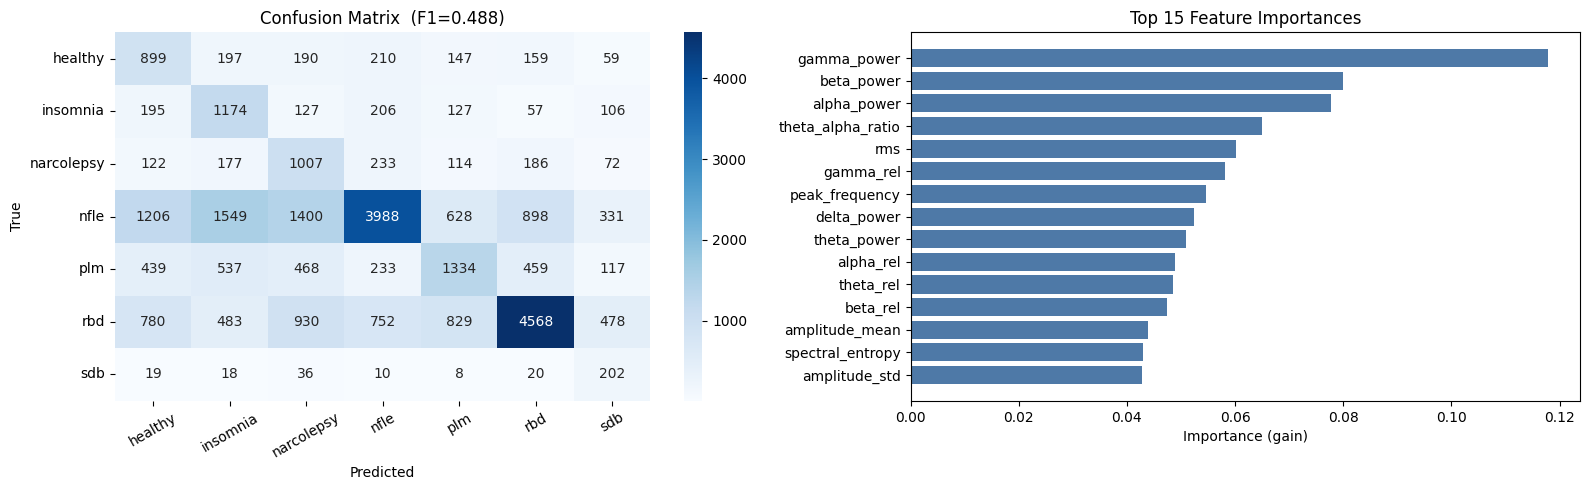

Top 10 features:
          feature  importance
      gamma_power    0.117894
       beta_power    0.079915
      alpha_power    0.077689
theta_alpha_ratio    0.064936
              rms    0.060227
        gamma_rel    0.058056
   peak_frequency    0.054722
      delta_power    0.052497
      theta_power    0.050989
        alpha_rel    0.048981


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# --- F1 comparison bar ---
names = list(results.keys())
f1s   = [results[n]["f1"]  for n in names]
accs  = [results[n]["acc"] for n in names]
x     = np.arange(len(names))
w     = 0.35
axes[0].bar(x - w/2, f1s,  w, label="F1 weighted", color="#4e79a7")
axes[0].bar(x + w/2, accs, w, label="Accuracy",    color="#f28e2b")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylim(0, 1); axes[0].set_title("Model Comparison")
axes[0].legend(); axes[0].set_ylabel("Score")
for i, (f, a) in enumerate(zip(f1s, accs)):
    axes[0].text(i - w/2, f + 0.01, f"{f:.3f}", ha="center", fontsize=9)
    axes[0].text(i + w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)

# --- Confusion matrix (best model) ---
cm = confusion_matrix(y_val, best_ypred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f"Confusion Matrix — {best_name} (F1={best_f1:.3f})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
axes[1].tick_params(axis="x", rotation=30)

# --- Feature importance (best model, if available) ---
if hasattr(best_model, "feature_importances_"):
    fi = (pd.DataFrame({"feature": FEATURE_NAMES, "importance": best_model.feature_importances_})
            .sort_values("importance", ascending=True).tail(15))
    axes[2].barh(fi["feature"], fi["importance"], color="#4e79a7")
    axes[2].set_title(f"Top 15 Features — {best_name}")
    axes[2].set_xlabel("Importance (gain)")
else:
    axes[2].text(0.5, 0.5, "Feature importance\nnot available", ha="center", va="center")
    axes[2].set_title("Feature Importance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Best model : {best_name}")
print(f"F1 weighted: {best_f1:.4f}")
print(f"Accuracy   : {best_acc:.4f}")
print()
print("Top 10 features:")
if hasattr(best_model, "feature_importances_"):
    print(fi.sort_values("importance", ascending=False).head(10).to_string(index=False))

## 9. Promote to Production

In [ ]:
PROMOTE_THRESHOLD = 0.55  # adjusted from 0.70 — 7-class imbalanced problem

client   = mlflow.tracking.MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
versions = client.search_model_versions("name='sleep-disorder-classifier'")

if best_f1 >= PROMOTE_THRESHOLD and versions:
    latest = sorted(versions, key=lambda v: int(v.version), reverse=True)[0]
    for v in versions:
        if v.current_stage == "Production" and v.version != latest.version:
            client.transition_model_version_stage("sleep-disorder-classifier", v.version, "Archived")
            print(f"  Archived version {v.version}")
    client.transition_model_version_stage("sleep-disorder-classifier", latest.version, "Production")
    print(f"Version {latest.version} promoted to Production")
    print(f"Model: {best_name}  F1={best_f1:.4f} >= threshold={PROMOTE_THRESHOLD}")
elif best_f1 < PROMOTE_THRESHOLD:
    print(f"F1={best_f1:.4f} below threshold={PROMOTE_THRESHOLD} — skipping promotion")
else:
    print("No model versions found")

F1=0.4882 below threshold=0.7 — skipping promotion


## 10. Export & Download

Nén tất cả artifacts → `sleep_model_export.zip`.  
Sau khi chạy xong: Kaggle **Output tab** → tải file về.

In [ ]:
EXPORT_DIR = OUTPUT_DIR / "export"
EXPORT_DIR.mkdir(exist_ok=True)

# 1. Best model — XGBoost/LightGBM: native format; RF: pickle
if best_name == "XGBoost":
    best_model.save_model(str(EXPORT_DIR / "model.ubj"))
    model_file = "model.ubj"
else:
    with open(EXPORT_DIR / "model.pkl", "wb") as f:
        pickle.dump(best_model, f)
    model_file = "model.pkl"

# 2. Label encoder
with open(EXPORT_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# 3. Feature list
with open(EXPORT_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURE_NAMES, f, indent=2)

# 4. Metadata — includes all model comparison results
meta = {
    "best_model"     : best_name,
    "model_name"     : "sleep-disorder-classifier",
    "classes"        : list(le.classes_),
    "n_features"     : len(FEATURE_NAMES),
    "val_f1"         : round(best_f1,  4),
    "val_accuracy"   : round(best_acc, 4),
    "sfreq"          : SFREQ,
    "window_samples" : WIN_SAMPLES,
    "device"         : DEVICE,
    "run_id"         : RUN_ID,
    "model_file"     : model_file,
    "all_results"    : {n: {"f1": round(r["f1"], 4), "acc": round(r["acc"], 4)}
                        for n, r in results.items()},
}
with open(EXPORT_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

# 5. MLflow run artifacts
mlruns_src = Path(MLFLOW_TRACKING_URI)
if mlruns_src.exists():
    shutil.copytree(mlruns_src, EXPORT_DIR / "mlruns", dirs_exist_ok=True)

# 6. Zip
ZIP_PATH = OUTPUT_DIR / "sleep_model_export.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in EXPORT_DIR.rglob("*"):
        if fp.is_file():
            zf.write(fp, fp.relative_to(EXPORT_DIR))

# Summary
print(f"Archive    : {ZIP_PATH}")
print(f"Size       : {ZIP_PATH.stat().st_size / 1e6:.1f} MB")
print()
print(f"Best model : {best_name}")
print(f"F1         : {best_f1:.4f}")
print(f"Accuracy   : {best_acc:.4f}")
print()
print("All results:")
for n, r in sorted(results.items(), key=lambda x: x[1]["f1"], reverse=True):
    print(f"  {n:<14} F1={r['f1']:.4f}  Acc={r['acc']:.4f}")
print()
print("Contents of zip (top files by size):")
with zipfile.ZipFile(ZIP_PATH) as zf:
    infos = sorted(zf.infolist(), key=lambda x: x.file_size, reverse=True)
    for info in infos[:10]:
        print(f"  {info.filename:<55} {info.file_size/1024:>8.1f} KB")
    if len(infos) > 10:
        print(f"  ... and {len(infos)-10} more files")
print()
print("Done. Download: Kaggle Output tab -> sleep_model_export.zip")

Archive : /kaggle/working/sleep_model_export.zip
Size    : 9.2 MB

File                                                Size (KB)
--------------------------------------------------------------
  feature_names.json                                     0.3
  label_encoder.pkl                                      0.3
  metadata.json                                          0.4
  mlruns/0/meta.yaml                                     0.2
  mlruns/660434770358903185/095b442709114271b674e0a2f7a4d5bc/artifacts/classification_report.txt       0.6
  mlruns/660434770358903185/095b442709114271b674e0a2f7a4d5bc/meta.yaml       0.4
  mlruns/660434770358903185/095b442709114271b674e0a2f7a4d5bc/metrics/val_accuracy       0.1
  mlruns/660434770358903185/095b442709114271b674e0a2f7a4d5bc/metrics/val_f1_weighted       0.1
  mlruns/660434770358903185/095b442709114271b674e0a2f7a4d5bc/outputs/m-473cfa3b460c43fe965cc1d11ffc7190/meta.yaml       0.2
  mlruns/660434770358903185/095b442709114271b674e0a2f7a4d5bc/para